In [262]:
%pip install xgboost
%pip install catboost

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   --- ------------------------------------ 7.6/100.2 MB 53.8 MB/s eta 0:00:02
   -------- ------------------------------- 21.0/100.2 MB 59.2 MB/s eta 0:00:02
   ------------ --------------------------- 32.2/100.2 MB 56.2 MB/s eta 0:00:02
   ---------------- ----------------------- 41.9/100.2 MB 54.8 MB/s eta 0:00:02
   -------------------- ------------------- 52.4/100.2 MB 53.8 MB/s eta 0:00:01
   ------------------------ --------------- 61.6/100.2 MB 52.3 MB/s eta 0:00:01
   ---------------------------- ----------- 71.3/100.2 MB 51.3 MB/s eta 0:00:01
   -------------------------------- ------- 81.8/100.2 MB 51.1 MB/s eta 0:00:01
   ------------------------------------ --- 92.0/100.2 MB 50.8 MB/s eta 0:00:01
   --------------------------------------  100.1/100.2 MB 50.8 MB/s eta 0:00:01
   ---------------------------------------- 100.2/100.2 MB 48.6 

In [263]:
import numpy as np
import pandas as pd
import os
from sklearn.metrics import ConfusionMatrixDisplay

import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import joblib
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

from catboost import CatBoostClassifier

In [217]:
dir = os.getcwd()
print(dir)

C:\Users\grego\OneDrive\Documents\Projects\App_PredictFlakingType


In [238]:
df.columns

Index(['Flaking condition', 'FlakeTermination', 'PlatformDelineation',
       'Lipping', 'PlatformMorphology', 'TechLength', 'MaxTechWidth',
       'MaxThickness', 'PlatformWidth', 'PlatformThickness',
       'ExteriorPlatAngle', 'Mass', 'Curvature'],
      dtype='object')

In [239]:
df = pd.read_csv(dir+"/Quartz energetics_flakes.csv")

df = df[df['Completeness'] == 'Complete']

cols_drop = ['DateOfDataEntry', 'CoreNumber', 'ToolNumber', 'QuartzGrainSize', 'QuartzGrain',
             'QuartzPlane', 'LithicArtifactClass', 'Completeness', 'Notes', 'Photograph',
            'NumberPlatformScars', 'CortexLocation', 'ReboundForce', 'DorsalPrep',
            'FissuringOnPlatform', 'MarksVentralSurface', 'DiagnosticImpactFractures',
            'EvidenceBipolarPercussion','MaxWidth', 'MidThickness', 'PlatformPrep', 'PlatAbrasion',
            'EdgeDamage', 'EPACaliper', 'MaxLength',
            # Test dropping
            'TechnicalCategory', 'FlakeProfile', 'CortexArea', 'FractureInitiationPoint','FractureInitiationPoint','PlatformCortex',
            
            #Test 2
            'DorsalScarCount', 'DorsalDirection', 'ArisOrientation', 'CrossSectionType', 'ProfileTwisted?',
            
            # Test 3
            'Curvature','ExteriorPlatAngle','PlatformMorphology', 'PlatformDelineation']

cols_to_drop = [col for col in cols_drop if col in df.columns]
df.drop(cols_to_drop, inplace=True, axis = 1)

Best Params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


C:\Users\grego\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
25 fits failed out of a total of 75.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\grego\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\grego\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\grego\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.fit

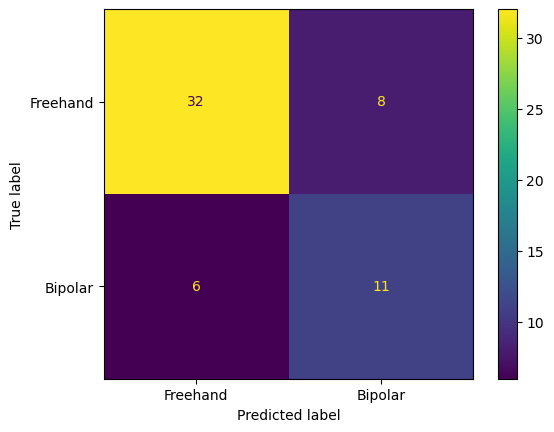

                            Coefficient
FlakeTermination_Overshoot     2.300841
PlatformThickness              2.164713
FlakeTermination_Feather       1.563662
MaxTechWidth                   0.909830
FlakeTermination_Axial         0.821243
PlatformWidth                  0.075679
Accuracy: 0.75
Type I Error Rate: 0.20
Type II Error Rate: 0.35


['flaking_pipeline.pkl']

In [257]:
X = df.drop(['Flaking condition'], axis = 1)
y = df['Flaking condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)

numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include = 'object').columns.tolist()

num_pipeline = Pipeline([
    ("imputer", IterativeImputer()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression())
])

# Corrected parameter grid with proper prefixes
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100], 
    'model__penalty': ['l1', 'l2', 'none'],      
    'model__solver': ['liblinear']        
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

# Fixed variable name from grid_search to grid
print(f"Best Params: {grid.best_params_}")

# Fixed variable name from grid_search to grid
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)



cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Freehand', 'Bipolar'])
disp.plot()
plt.show()

preprocessor = best_model.named_steps['preprocess']
model = best_model.named_steps['model']  # Access the model step

# Get feature names after one-hot encoding
feature_names = []
if numeric_features:
    feature_names.extend(numeric_features)
if categorical_features:
    # Get the one-hot encoded feature names
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_features = ohe.get_feature_names_out(categorical_features)
    feature_names.extend(cat_features)

# Create DataFrame with coefficients
coef_df = pd.DataFrame(
    model.coef_[0],  # Access coef_ from the model, not the pipeline
    index=feature_names,
    columns=['Coefficient']
).sort_values(by='Coefficient', ascending=False)

print(coef_df[coef_df['Coefficient'] > 0])

# Extract counts from the confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Proportion Correct
accuracy = accuracy_score(y_test, y_pred)

# Type I Error Rate (False Positive Rate)
type_i_error = fp / (fp + tn)

# Type II Error Rate (False Negative Rate)
type_ii_error = fn / (fn + tp)

print(f"Accuracy: {accuracy:.2f}")
print(f"Type I Error Rate: {type_i_error:.2f}")
print(f"Type II Error Rate: {type_ii_error:.2f}")

In [222]:
df.drop(['Flaking condition'], axis = 1).to_csv('Test.csv', index = False)

# Random Forest Classifier

Best Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}


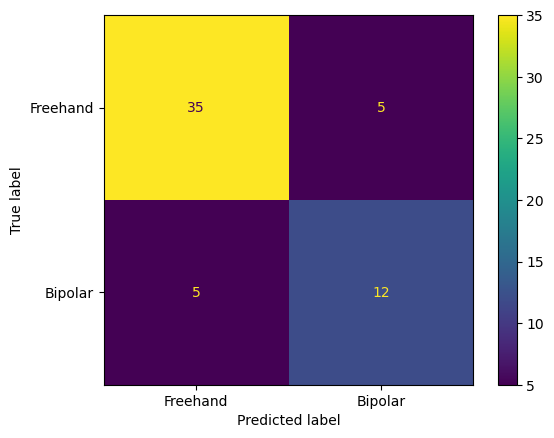

In [258]:
X = df.drop(['Flaking condition'], axis = 1)
y = df['Flaking condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)

numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include = 'object').columns.tolist()

num_pipeline = Pipeline([
    ("imputer", IterativeImputer()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier())
])

# Corrected parameter grid with proper prefixes
param_grid = {
    'model__n_estimators': [100, 150, 200],
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 7, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

# Fixed variable name from grid_search to grid
print(f"Best Params: {grid.best_params_}")

# Fixed variable name from grid_search to grid
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)



cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Freehand', 'Bipolar'])
disp.plot()
plt.show()

preprocessor = best_model.named_steps['preprocess']
model = best_model.named_steps['model']  # Access the model step

# Extract counts from the confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Proportion Correct
accuracy = accuracy_score(y_test, y_pred)

# Type I Error Rate (False Positive Rate)
type_i_error = fp / (fp + tn)

# Type II Error Rate (False Negative Rate)
type_ii_error = fn / (fn + tp)

print(f"Accuracy: {accuracy:.2f}")
print(f"Type I Error Rate: {type_i_error:.2f}")
print(f"Type II Error Rate: {type_ii_error:.2f}")

## XGBoost

Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__subsample': 1.0}


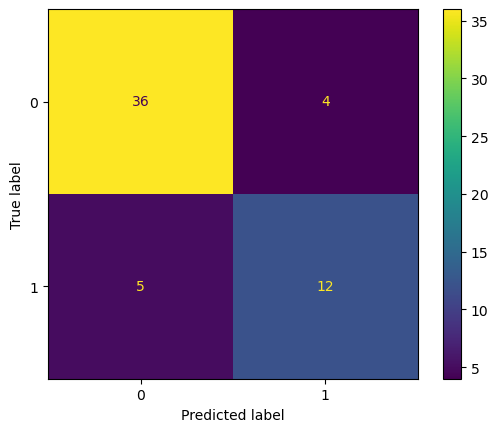

Accuracy: 0.84
Type I Error Rate: 0.10
Type II Error Rate: 0.29


['flaking_pipeline.pkl']

In [278]:
X = df.drop(['Flaking condition'], axis = 1)
y_encoded = df["Flaking condition"].map({"Freehand": 1, "Bipolar": 0})

#label_encoder = LabelEncoder()

#y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=777)

numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(include = 'object').columns.tolist()

num_pipeline = Pipeline([
    ("imputer", IterativeImputer()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(eval_metric='logloss'))
])

# Corrected parameter grid with proper prefixes
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 6, 9],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.8, 1.0]
}


grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

# Fixed variable name from grid_search to grid
print(f"Best Params: {grid.best_params_}")

# Fixed variable name from grid_search to grid
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)



cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Extract counts from the confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Proportion Correct
accuracy = accuracy_score(y_test, y_pred)

# Type I Error Rate (False Positive Rate)
type_i_error = fp / (fp + tn)

# Type II Error Rate (False Negative Rate)
type_ii_error = fn / (fn + tp)

print(f"Accuracy: {accuracy:.2f}")
print(f"Type I Error Rate: {type_i_error:.2f}")
print(f"Type II Error Rate: {type_ii_error:.2f}")

joblib.dump(grid.best_estimator_, "flaking_pipeline.pkl")

## CatBoost

In [290]:
from platform import python_version
print(python_version())

3.13.9
